# Selective Prediction Tutorial

Selective prediction lets a model say "I don't know" — rejecting predictions where uncertainty is too high. This improves reliability at the cost of coverage.

**Key metrics:**
- **Coverage:** fraction of inputs the model accepts
- **Selective Risk:** error rate on accepted inputs only
- **AURC:** Area Under Risk-Coverage curve (lower = better)

A model with good uncertainty should achieve low risk at high coverage — rejecting only truly hard/OOD examples.

# Selective Prediction

Reject uncertain predictions to improve reliability.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from deepuq.models import MLP
from deepuq.methods.selective import SelectivePredictor
from deepuq.methods.mc_dropout import MCDropoutWrapper

## Setup

In [2]:
np.random.seed(42)

# Generate data with OOD region (gap between -1 and 1)
x_train_left = np.random.uniform(-3, -1, 50).astype(np.float32)
x_train_right = np.random.uniform(1, 3, 50).astype(np.float32)
x_train = np.concatenate([x_train_left, x_train_right])
y_train = (np.sin(x_train) + np.random.normal(0, 0.1, 100)).astype(np.float32)
x_test = np.linspace(-5, 5, 200).astype(np.float32)
y_test = np.sin(x_test).astype(np.float32)

x_train_t = torch.from_numpy(x_train).unsqueeze(-1)
y_train_t = torch.from_numpy(y_train).unsqueeze(-1)
x_test_t = torch.from_numpy(x_test).unsqueeze(-1)
y_test_t = torch.from_numpy(y_test).unsqueeze(-1)

# Train MLP with dropout
model = MLP(1, [64, 64], 1, p_drop=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = torch.nn.MSELoss()

for epoch in range(300):
    model.train()
    optimizer.zero_grad()
    loss = loss_fn(model(x_train_t), y_train_t)
    loss.backward()
    optimizer.step()

print(f"Final training loss: {loss.item():.4f}")

# Wrap with MC Dropout
mc_model = MCDropoutWrapper(model, n_mc=50, apply_softmax=False)

Final training loss: 0.0210


## Selective Prediction

## Coverage-Risk Tradeoff

By varying the uncertainty threshold, we trade off coverage for risk. A stricter threshold rejects more predictions (lower coverage) but keeps only the most confident ones (lower risk). The optimal threshold depends on the application's tolerance for errors vs. the cost of abstaining.

In [3]:
# Create selective predictor
selector = SelectivePredictor(mc_model)

# Find threshold for 80% coverage
threshold = selector.find_threshold(x_test_t, y_test_t, target_coverage=0.8)
print(f"Threshold for 80% coverage: {threshold:.4f}")

# Predict with rejection
result = selector.predict_with_rejection(x_test_t, threshold=threshold, y=y_test_t)
print(f"Accepted: {result.accepted_mask.sum()}/{len(result.accepted_mask)} predictions ({100*result.coverage:.1f}%)")

Threshold for 80% coverage: 0.0130
Accepted: 151/200 predictions (75.5%)


## Evaluate

## Evaluating Selective Prediction: AURC

The Area Under the Risk-Coverage curve (AURC) summarizes selective prediction quality in a single number. It measures the average risk across all coverage levels. Lower AURC means the model concentrates its errors on the predictions it is least confident about — exactly what we want.

In [4]:
# Evaluate selective prediction
metrics = selector.evaluate(x_test_t, y_test_t)
print(f"Coverage: {metrics.coverage:.3f}")
print(f"Selective MSE: {metrics.selective_mse:.4f}")
print(f"AURC: {metrics.aurc:.4f}")

Coverage: 1.000
Selective MSE: 0.1993
AURC: 0.3890


## Risk-Coverage Tradeoff

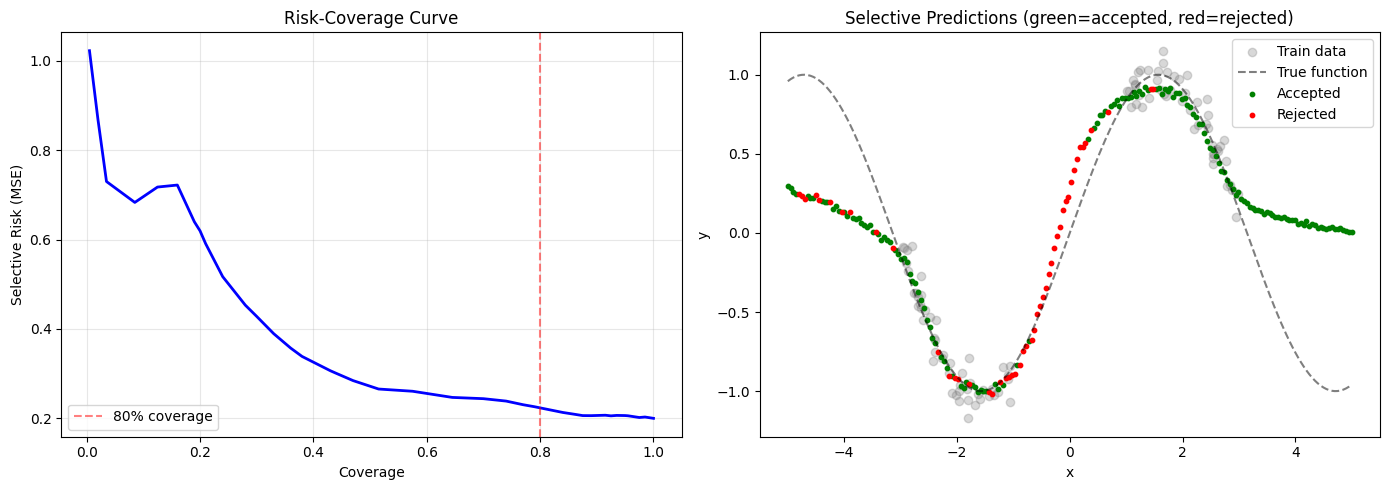

In [5]:
# Get predictions and uncertainty from the MC model
uq_result = mc_model.predict_uq(x_test_t)
mean = uq_result.mean.squeeze()
std = uq_result.total_var.sqrt().squeeze()

# Plot risk vs coverage at different thresholds
thresholds = np.linspace(0.01, std.numpy().max(), 50)
coverages_list = []
risks_list = []

mean_np = mean.numpy()
std_np = std.numpy()

for t in thresholds:
    accepted = std_np <= t
    cov = accepted.mean()
    if cov > 0:
        risk = ((mean_np[accepted] - y_test[accepted]) ** 2).mean()
    else:
        risk = np.nan
    coverages_list.append(cov)
    risks_list.append(risk)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk-coverage curve
axes[0].plot(coverages_list, risks_list, "b-", linewidth=2)
axes[0].axvline(x=0.8, color="r", linestyle="--", alpha=0.5, label="80% coverage")
axes[0].set_xlabel("Coverage")
axes[0].set_ylabel("Selective Risk (MSE)")
axes[0].set_title("Risk-Coverage Curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Spatial visualization
accepted_mask = result.accepted_mask.numpy()
axes[1].scatter(x_train, y_train, alpha=0.3, label="Train data", color="gray")
axes[1].plot(x_test, np.sin(x_test), "k--", alpha=0.5, label="True function")
axes[1].scatter(x_test[accepted_mask], mean_np[accepted_mask],
               color="green", s=10, label="Accepted")
axes[1].scatter(x_test[~accepted_mask], mean_np[~accepted_mask],
               color="red", s=10, label="Rejected")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title("Selective Predictions (green=accepted, red=rejected)")
axes[1].legend()

plt.tight_layout()
plt.show()